In [1]:
#importing libraries

In [4]:
import pandas as pd
import numpy as np
import os

In [3]:
#import data from my disk

In [4]:
nav = pd.read_csv("C:/Users/Bhanu Bisht/Data_Analytics_Project/data/raw/02_nav_history.csv")

In [6]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [7]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [8]:
nav.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [9]:
nav.shape

(46000, 3)

In [10]:
nav.dtypes

amfi_code      int64
date          object
nav          float64
dtype: object

In [11]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [12]:
# date dtype is object change in datetime

In [13]:
## 1. Parse dates
nav['date'] = pd.to_datetime(nav['date'])

In [14]:
nav['date']

0       2022-01-03
1       2022-01-04
2       2022-01-05
3       2022-01-06
4       2022-01-07
           ...    
45995   2026-05-25
45996   2026-05-26
45997   2026-05-27
45998   2026-05-28
45999   2026-05-29
Name: date, Length: 46000, dtype: datetime64[ns]

In [15]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


# Fund Performance Analytics

# 1st instruction according to project

# Compute daily returns — daily_return = nav_t / nav_t-1 − 1 for all 40 schemes. Validate distribution looks reasonable.

In [16]:
# Step 1: Check the number of schemes

In [17]:
nav["amfi_code"].nunique()

40

In [18]:
# Step 2: Sort the data

In [19]:
nav = nav.sort_values(["amfi_code", "date"])

In [20]:
nav.head(2)

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971


In [21]:
# Step 3: Compute Daily Returns

In [22]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
          .pct_change()
)

In [23]:
nav['daily_return']

5750          NaN
5751    -0.010306
5752     0.012865
5753    -0.011377
5754    -0.001210
           ...   
45995    0.012106
45996   -0.004138
45997   -0.008480
45998   -0.028093
45999   -0.003335
Name: daily_return, Length: 46000, dtype: float64

In [25]:
# The first row of each scheme is NaN because there is no previous NAV

In [24]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [26]:
# Step 4: Validate the Distribution

In [27]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [29]:
#Histogram

In [30]:
# we use matplotlib library for data visualization

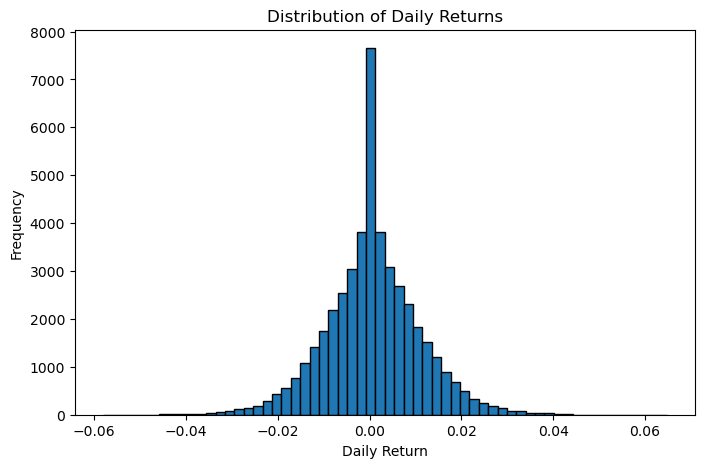

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=60,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [31]:
# Boxplot

In [33]:
# This helps identify outliers

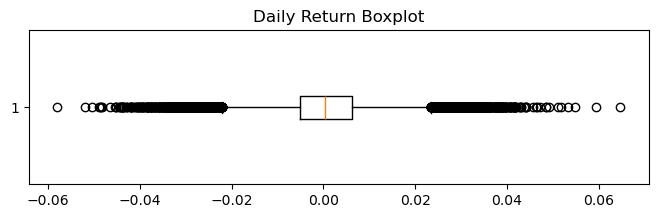

In [32]:
plt.figure(figsize=(8,2))

plt.boxplot(nav["daily_return"].dropna(), vert=False)

plt.title("Daily Return Boxplot")

plt.show()

In [34]:
# Check extreme values

#Largest positive returns:

In [35]:
nav.nlargest(10, "daily_return")

,amfi_code,date,nav,daily_return
2895,119598,2024-04-15,189.0742,0.064713
20126,118634,2024-03-19,110.5401,0.059304
33957,101207,2024-05-01,65.5882,0.054851
3716,119599,2023-01-10,153.2221,0.053320
3982,119599,2024-01-17,136.8239,0.051811
2305,119598,2022-01-10,96.0964,0.051113
2521,119598,2022-11-08,123.9704,0.049051
45082,149324,2022-11-23,98.3696,0.048490
2506,119598,2022-10-18,122.2757,0.048454
3241,119598,2025-08-12,200.8460,0.047123


In [36]:
# Largest negative returns:

In [38]:
nav.nsmallest(10, "daily_return")

,amfi_code,date,nav,daily_return
19674,118634,2022-06-24,67.2534,-0.058102
33667,101207,2023-03-22,56.8326,-0.051847
19852,118634,2023-03-01,113.5801,-0.050335
45312,149324,2023-10-11,111.8155,-0.048870
34310,101207,2025-09-08,62.3200,-0.048634
31304,119095,2022-12-23,73.9946,-0.048367
20233,118634,2024-08-15,114.5168,-0.048305
31807,119095,2024-11-27,78.1317,-0.046524
4198,119599,2024-11-14,112.8996,-0.045429
9770,125498,2024-03-11,131.4556,-0.045218


In [39]:
# Check missing values

In [40]:
nav["daily_return"].isna().sum()

np.int64(40)

# 2nd instruction according to project

In [41]:
# Compute CAGR for 1yr, 3yr, 5yr — CAGR = (NAV_end / NAV_start) ^ (1/n) − 1. Build a comparison table across all funds.

In [43]:
# You need to calculate the Compound Annual Growth Rate (CAGR) for each mutual fund scheme over:
#1 year
# 3 years
# 5 years

In [44]:
# Step 1: Sort the data

In [45]:
nav = nav.sort_values(["amfi_code", "date"])

In [46]:
nav.head(2)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306


In [47]:
# Step 2: Get the latest date

In [48]:
latest_date = nav["date"].max()
print(latest_date)

2026-05-29 00:00:00


In [49]:
# Step 3: Create start dates

In [50]:

date_1y = latest_date - pd.DateOffset(years=1)
date_3y = latest_date - pd.DateOffset(years=3)
date_5y = latest_date - pd.DateOffset(years=5)

In [51]:
# Step 4: Create a function to calculate CAGR

In [62]:
def calculate_cagr(nav, years):
    latest_date = nav["date"].max()
    start_date = latest_date - pd.DateOffset(years=years)

    result = []

    for scheme, group in nav.groupby("amfi_code"):

        group = group.sort_values("date")

        # first NAV on/after start date
        start = group[group["date"] >= start_date].head(1)

        # latest NAV
        end = group.tail(1)

        if start.empty or end.empty:
            continue

        nav_start = start["nav"].values[0]
        nav_end = end["nav"].values[0]

        cagr = (nav_end / nav_start) ** (1 / years) - 1

        result.append({
            "amfi_code": scheme,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(result)

In [53]:
# Step 5: Calculate all three

In [63]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [55]:
# Step 6: Build the comparison table

In [64]:
cagr_table = (
    cagr_1
    .merge(cagr_3, on="amfi_code")
    .merge(cagr_5, on="amfi_code")
)

In [57]:
# Step 7: Convert to percentages

In [65]:
cagr_table.iloc[:, 1:] *= 100

cagr_table.iloc[:, 1:] = cagr_table.iloc[:, 1:].round(2)

In [59]:
# Step 8: View the result

In [66]:
cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


# 3rd instruction according to project 

In [67]:
# Sharpe Ratio — (Rp − Rf) / Std(Rp) × √252. Use Rf = 6.5% (RBI repo rate proxy). Rank all 40 funds

In [68]:
# Sharpe Ratio = (Rp − Rf) / Std(Rp) × √252

# Use Rf = 6.5% (risk-free rate).

#Rank all 40 funds.

In [69]:
#Calculate the average daily return for each scheme.
#Calculate the daily return standard deviation (volatility) for each scheme.
#Convert the annual risk-free rate (6.5%) to a daily risk-free rate.
#Calculate the Sharpe Ratio.
#Rank all schemes from highest to lowest Sharpe Ratio.

In [70]:
# Step 1:  dataframe

In [71]:
nav

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
...,...,...,...,...
45995,149324,2026-05-25,292.4810,0.012106
45996,149324,2026-05-26,291.2707,-0.004138
45997,149324,2026-05-27,288.8007,-0.008480
45998,149324,2026-05-28,280.6873,-0.028093


In [73]:
# Step 1: Set the Risk-Free Rate
# Use Rf = 6.5% (RBI repo rate proxy)

In [74]:
rf = 0.065          # Annual risk-free rate (6.5%)
daily_rf = rf / 252 # Convert annual rate to daily rate

In [75]:
# Step 3: Calculate Mean Return and Standard Deviation

In [76]:
# Group the data by amfi_code and calculate the average and standard deviation of daily returns.

In [77]:
sharpe_df = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(
           mean_return="mean",
           std_return="std"
       )
       .reset_index()
)

In [79]:
sharpe_df.head(2)

,amfi_code,mean_return,std_return
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460


In [81]:
# Step 4: Calculate Sharpe Ratio

In [82]:
# # Sharpe Ratio = (Rp − Rf) / Std(Rp) × √252

In [83]:
sharpe_df["Sharpe_Ratio"] = (
    (sharpe_df["mean_return"] - daily_rf)
    / sharpe_df["std_return"]
) * np.sqrt(252)

In [84]:
# Step 5: Rank All Funds

In [85]:
# Higher Sharpe Ratio = Better performance.

In [86]:
sharpe_df["Rank"] = (
    sharpe_df["Sharpe_Ratio"]
        .rank(method="dense", ascending=False)
        .astype(int)
)

In [87]:
# Step 6: Sort by Rank

In [88]:
sharpe_df = sharpe_df.sort_values("Rank")

In [89]:
# Step 7: View the Results

In [90]:
sharpe_df.head(10)

,amfi_code,mean_return,std_return,Sharpe_Ratio,Rank
34,148567,0.001074,0.008941,1.448291,1
30,120843,0.001082,0.010008,1.306744,2
36,148569,0.001124,0.011134,1.234930,3
19,119551,0.000917,0.008656,1.208267,4
25,120505,0.001161,0.012152,1.180101,5
38,149323,0.001055,0.011179,1.132122,6
2,100033,0.001080,0.011929,1.093699,7
9,118632,0.000865,0.008913,1.081659,8
3,101206,0.000852,0.009177,1.027213,9
24,120504,0.000843,0.009048,1.026524,10


In [95]:
# Step 8 Round the Values
# This rounds mean_return &  std_return & Sharpe_Ratio to 6 decimal places.

In [92]:
sharpe_df["mean_return"] = sharpe_df["mean_return"].round(6)
sharpe_df["std_return"] = sharpe_df["std_return"].round(6)
sharpe_df["Sharpe_Ratio"] = sharpe_df["Sharpe_Ratio"].round(3)

In [94]:
sharpe_df.head(5)

,amfi_code,mean_return,std_return,Sharpe_Ratio,Rank
34,148567,0.001074,0.008941,1.448,1
30,120843,0.001082,0.010008,1.307,2
36,148569,0.001124,0.011134,1.235,3
19,119551,0.000917,0.008656,1.208,4
25,120505,0.001161,0.012152,1.180,5


# instruction 4 according to project

In [96]:
#Sortino Ratio — same formula but denominator uses only downside standard deviation (negative return days only).

In [106]:
# Step 1: Define downside standard deviation

In [107]:
def downside_std(x):
    negative_returns = x[x < 0]
    return negative_returns.std()

In [108]:
# Step 2: Calculate mean return and downside standard deviation

In [109]:


rf_annual = 0.065
rf_daily = rf_annual / 252

sortino_df = nav.groupby("amfi_code").agg(
    mean_return=("daily_return", "mean")
).reset_index()

# Downside standard deviation
sortino_df["downside_std"] = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(downside_std)
       .values
)

In [110]:
# Step 3: Calculate Sortino Ratio

In [111]:
sortino_df["Sortino_Ratio"] = (
    (sortino_df["mean_return"] - rf_daily)
    / sortino_df["downside_std"]
) * np.sqrt(252)

In [112]:
# Step 4: Rank the funds

In [113]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["Rank"] = sortino_df.index + 1

In [114]:
#Step 5: Display the result

In [116]:
sortino_df.head(2)

,amfi_code,mean_return,downside_std,Sortino_Ratio,Rank
0,148567,0.001074,0.005428,2.385644,1
1,120843,0.001082,0.005531,2.364320,2


In [117]:
sharpe_df.head(2)

,amfi_code,mean_return,std_return,Sharpe_Ratio,Rank
34,148567,0.001074,0.008941,1.448,1
30,120843,0.001082,0.010008,1.307,2


In [118]:
nav.head(2)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306


# instruction 5th according to instruction

In [122]:
#Alpha and Beta — OLS regression of fund returns on Nifty 100 returns using scipy.stats.linregress. Alpha = intercept × 252.

In [123]:
# import benchmark dataset

In [192]:
benchmark = pd.read_csv("C:/Users/Bhanu Bisht/Data_Analytics_Project/data/raw/10_benchmark_indices.csv")

In [193]:
benchmark.head(2)

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64


In [194]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [195]:
benchmark.dtypes

date            object
index_name      object
close_value    float64
dtype: object

In [128]:
# date dtype is object change in datetime

In [196]:
## 1. Parse dates
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [200]:
benchmark['date'].head()

0   2022-01-03
1   2022-01-04
2   2022-01-05
3   2022-01-06
4   2022-01-07
Name: date, dtype: datetime64[ns]

In [201]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[ns]
 1   index_name   8050 non-null   object        
 2   close_value  8050 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 188.8+ KB


In [202]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46000 entries, 5750 to 45999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   amfi_code     46000 non-null  int64         
 1   date          46000 non-null  datetime64[ns]
 2   nav           46000 non-null  float64       
 3   daily_return  45960 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.8 MB


In [204]:
benchmark.head(2)

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64


In [206]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
21850,118636,2022-01-03,30.1152,NaN
27600,119092,2022-01-03,38.7466,NaN
28750,119093,2022-01-03,41.8140,NaN
18400,118633,2022-01-03,47.1836,NaN


In [207]:
nav["daily_return"].unique()

array([        nan, -0.01467883, -0.00656058, ..., -0.00080852,
        0.01049982, -0.00333538])

In [134]:
# Step 1: Filter the benchmark to Nifty 100

In [178]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [179]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

In [180]:
nav = nav.sort_values("date")
benchmark = benchmark.sort_values("date")

In [137]:
# Step 2: Calculate benchmark daily returns

In [181]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

In [182]:
nifty100.head(2)

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.01354


In [183]:
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

In [140]:
#Step 3: Merge benchmark returns with fund returns

In [184]:
merged = nav.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

In [185]:
merged.head(2)

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,118636,2022-01-03,30.1152,NaN,NaN


In [186]:
fund = merged[merged["amfi_code"] == 100016]

fund[["daily_return", "benchmark_return"]].corr()

,daily_return,benchmark_return
daily_return,1.000000,-0.051624
benchmark_return,-0.051624,1.000000


In [187]:
fund[["date", "daily_return", "benchmark_return"]].head(10)

,date,daily_return,benchmark_return
0,2022-01-03,NaN,NaN
43,2022-01-04,-0.010306,-0.013540
102,2022-01-05,0.012865,0.004003
126,2022-01-06,-0.011377,-0.002935
162,2022-01-07,-0.001210,0.006150
227,2022-01-10,-0.008639,-0.008351
252,2022-01-11,0.005562,0.004942
282,2022-01-12,-0.002404,0.009128
341,2022-01-13,-0.004050,0.003746
369,2022-01-14,0.008073,-0.014098


In [145]:
#Step 4: Import linregress

In [148]:
# using scipy library for mathematical algorithms 

In [188]:
from scipy.stats import linregress

In [149]:
# Step 5: Run the regression for each fund

In [189]:
fund = fund.dropna(subset=["daily_return", "benchmark_return"]).reset_index(drop=True)

In [190]:
fund.head(1)

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,-0.01354


In [191]:
from scipy.stats import linregress

result = linregress(
    fund["benchmark_return"],
    fund["daily_return"]
)

beta = result.slope
alpha_daily = result.intercept
alpha_annual = alpha_daily * 252

print("Beta:", beta)
print("Daily Alpha:", alpha_daily)
print("Annual Alpha:", alpha_annual)
print("R²:", result.rvalue**2)

Beta: -0.05826843143880889
Daily Alpha: 0.00014871352235886037
Annual Alpha: 0.03747580763443281
R²: 0.002665032698133322


In [150]:
results = []

for code, df in merged.groupby("amfi_code"):

    df = df.dropna(subset=["daily_return", "benchmark_return"])

    regression = linregress(
        df["benchmark_return"],
        df["daily_return"]
    )

    results.append({
        "amfi_code": code,
        "Beta": regression.slope,
        "Alpha": regression.intercept * 252
    })

In [152]:
# Step 6: Convert to a DataFrame

In [153]:
alpha_beta = pd.DataFrame(results)

In [154]:
# Step 7: View the results


In [155]:
alpha_beta.head(5)

,amfi_code,Beta,Alpha
0,100016,-0.058268,0.037476
1,100025,0.001158,0.042818
2,100033,0.005104,0.271954
3,101206,0.021086,0.213998
4,101207,-0.065289,0.108971


In [156]:
#What do these values mean?
#Beta
'''Beta = 1.00 → Moves in line with the benchmark.
Beta > 1.00 → More volatile than the benchmark.
Beta < 1.00 → Less volatile than the benchmark.
Beta < 0 → Tends to move opposite to the benchmark (uncommon for equity funds).
'''
#Alpha

'''Since I am multiplying the intercept by 252, Alpha is annualized.

Positive Alpha → The fund outperformed what its Beta would predict.
Negative Alpha → The fund underperformed after adjusting for market risk.
Alpha ≈ 0 → Performance was about what would be expected given its Beta.
'''

'Since I am multiplying the intercept by 252, Alpha is annualized.\n\nPositive Alpha → The fund outperformed what its Beta would predict.\nNegative Alpha → The fund underperformed after adjusting for market risk.\nAlpha ≈ 0 → Performance was about what would be expected given its Beta.\n'

In [157]:
fund = merged[merged["amfi_code"] == 100016]

fund[["daily_return", "benchmark_return"]].corr()

,daily_return,benchmark_return
daily_return,1.000000,-0.051624
benchmark_return,-0.051624,1.000000


# 7th instruction

In [1]:
# Fund Scorecard (0–100) — composite: 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × expense ratio rank (inverse) + 10% × max DD rank (inverse).

In [3]:
fund_master= pd.read_csv("C:/Users/Bhanu Bisht/Data_Analytics_Project/data/raw/01_fund_master.csv")

NameError: name 'pd' is not defined